# The Financial Analyst – Natural Language to SQL with LLM

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This notebook implements a **Text‑to‑SQL system** that allows users to ask business questions in plain English and receive answers by querying a structured database. The system translates natural language to SQL, executes it, and returns a natural language response with the queried data.

This project demonstrates bridging unstructured language and structured data – a critical skill for AI‑powered business intelligence.

## Dataset
We use a **SQLite database** containing synthetic sales data:
- `products` (product_id, product_name, category, price)
- `sales` (sale_id, product_id, quantity, sale_date, region)
- `customers` (customer_id, name, segment)

The database is created and populated entirely within the notebook – no external uploads.

## Architecture
1. **Database Setup** – Create SQLite tables and insert sample financial data.
2. **Schema Awareness** – Provide the LLM with the table schemas.
3. **Text‑to‑SQL** – Use Groq (or a fallback LLM) to convert a user question into a SQL query.
4. **Execution** – Run the generated SQL on the SQLite database.
5. **Answer Generation** – Pass the query results back to the LLM to produce a final natural language answer.
6. **Error Handling** – Validate and retry or explain errors.

## Features
- Automatic schema extraction
- Caching of repeated questions (optional)
- Interactive Q&A loop
- Example questions provided

## Files Generated
- `finance.db` – SQLite database file (saved locally and optionally to Drive)

---

**© 2026 Ibrahim – Natural Language to SQL financial analyst.**

### Install Dependencies

In [1]:
# Author: Ibrahim

!pip install -q langchain langchain-community langchain-groq langchain-classic sqlalchemy pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


### Imports and Setup

In [2]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import create_sql_agent
from langchain_groq import ChatGroq
from langchain_classic.agents import AgentExecutor
from langchain_classic.tools import Tool
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Imports completed.")

Imports completed.


### Create SQLite Database with Sample Financial Data

In [3]:
# Create and populate a SQLite database
db_path = "finance.db"
conn = sqlite3.connect(db_path)

# Create tables
conn.executescript('''
DROP TABLE IF EXISTS products;
DROP TABLE IF EXISTS sales;
DROP TABLE IF EXISTS customers;

CREATE TABLE products (
    product_id INTEGER PRIMARY KEY,
    product_name TEXT,
    category TEXT,
    price REAL
);

CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    name TEXT,
    segment TEXT
);

CREATE TABLE sales (
    sale_id INTEGER PRIMARY KEY,
    product_id INTEGER,
    customer_id INTEGER,
    quantity INTEGER,
    sale_date TEXT,
    region TEXT,
    FOREIGN KEY (product_id) REFERENCES products(product_id),
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
);
''')

# Insert sample data
products_data = [
    (1, 'Laptop Pro', 'Electronics', 1200.00),
    (2, 'Wireless Mouse', 'Electronics', 25.99),
    (3, 'Desk Chair', 'Furniture', 199.99),
    (4, 'Coffee Mug', 'Kitchen', 12.50),
    (5, 'Monitor 27"', 'Electronics', 350.00),
    (6, 'Notebook', 'Stationery', 4.99),
]
conn.executemany("INSERT INTO products VALUES (?,?,?,?)", products_data)

customers_data = [
    (101, 'Alice Smith', 'Individual'),
    (102, 'Bob Johnson', 'Business'),
    (103, 'Carol White', 'Individual'),
    (104, 'David Brown', 'Business'),
]
conn.executemany("INSERT INTO customers VALUES (?,?,?)", customers_data)

sales_data = [
    (1, 1, 101, 2, '2025-01-15', 'North'),
    (2, 2, 101, 5, '2025-01-16', 'North'),
    (3, 3, 102, 1, '2025-01-17', 'South'),
    (4, 1, 103, 1, '2025-02-10', 'East'),
    (5, 4, 104, 20, '2025-02-11', 'West'),
    (6, 5, 102, 3, '2025-02-12', 'South'),
    (7, 6, 103, 50, '2025-02-13', 'East'),
    (8, 2, 101, 10, '2025-03-01', 'North'),
    (9, 3, 104, 2, '2025-03-02', 'West'),
    (10, 5, 103, 1, '2025-03-03', 'East'),
]
conn.executemany("INSERT INTO sales VALUES (?,?,?,?,?,?)", sales_data)
conn.commit()

print("Database created and populated.")
print("\nTables and row counts:")
for table in ['products', 'customers', 'sales']:
    count = pd.read_sql(f"SELECT COUNT(*) as cnt FROM {table}", conn).iloc[0,0]
    print(f"  {table}: {count} rows")
conn.close()

Database created and populated.

Tables and row counts:
  products: 6 rows
  customers: 4 rows
  sales: 10 rows


### Set Up Groq API Key and LLM

In [8]:
from getpass import getpass

GROQ_API_KEY = getpass("Enter your Groq API key: ")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0)
print("LLM initialized.")

Enter your Groq API key: ··········
LLM initialized.


### Connect to SQL Database via LangChain

In [9]:
db = SQLDatabase.from_uri("sqlite:///finance.db")
print("Database connected.")
print("Tables:", db.get_usable_table_names())
print("\nSchema preview:")
print(db.get_table_info())

Database connected.
Tables: ['customers', 'products', 'sales']

Schema preview:

CREATE TABLE customers (
	customer_id INTEGER, 
	name TEXT, 
	segment TEXT, 
	PRIMARY KEY (customer_id)
)

/*
3 rows from customers table:
customer_id	name	segment
101	Alice Smith	Individual
102	Bob Johnson	Business
103	Carol White	Individual
*/


CREATE TABLE products (
	product_id INTEGER, 
	product_name TEXT, 
	category TEXT, 
	price REAL, 
	PRIMARY KEY (product_id)
)

/*
3 rows from products table:
product_id	product_name	category	price
1	Laptop Pro	Electronics	1200.0
2	Wireless Mouse	Electronics	25.99
3	Desk Chair	Furniture	199.99
*/


CREATE TABLE sales (
	sale_id INTEGER, 
	product_id INTEGER, 
	customer_id INTEGER, 
	quantity INTEGER, 
	sale_date TEXT, 
	region TEXT, 
	PRIMARY KEY (sale_id), 
	FOREIGN KEY(product_id) REFERENCES products (product_id), 
	FOREIGN KEY(customer_id) REFERENCES customers (customer_id)
)

/*
3 rows from sales table:
sale_id	product_id	customer_id	quantity	sale_date	region


### Create SQL Agent (with safe execution)

In [10]:
# Create the SQL agent with a clear system prompt
from langchain_classic.agents import create_sql_agent
from langchain_classic.agents.agent_toolkits import SQLDatabaseToolkit

toolkit = SQLDatabaseToolkit(db=db, llm=llm)

agent = create_sql_agent(
    llm=llm,
    toolkit=toolkit,
    verbose=True,
    handle_parsing_errors=True,
    max_iterations=10,
    early_stopping_method="generate"
)

print("SQL agent ready.")

SQL agent ready.


### Define Clean Question‑Answer Function

In [11]:
def ask_financial_question(question):
    """Send a natural language question to the SQL agent and return answer."""
    try:
        result = agent.invoke({"input": question})
        answer = result["output"]
        # Optional: strip any extraneous formatting
        print(f"\n Question: {question}")
        print(f" Answer: {answer}")
        return answer
    except Exception as e:
        print(f"Error: {e}")
        return "Sorry, I couldn't process that question."

# Test with a simple question
test_q = "What is the total revenue from all sales? (revenue = price * quantity)"
ask_financial_question(test_q)



> Entering new SQL Agent Executor chain...
Question: What is the total revenue from all sales? (revenue = price * quantity)
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
Action: sql_db_list_tables
Action Input: customers, products, salesQuestion: What is the total revenue from all sales? (revenue = price * quantity)
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
Action: sql_db_list_tables
Action Input: customers, products, salesQuestion: What is the total revenue from all sales? (revenue = price * quantity)
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
Action: sql_db_list_tables
Action Input: customers, products, salesQuestion: What is the total revenue from all sales? (revenue = price * quantity)
Thought: I sh

"Sorry, I couldn't process that question."

### Interactive Q&A Loop

In [12]:
print("\n" + "="*50)
print("Financial Analyst (Text-to-SQL) Ready.")
print("Ask questions about sales, products, customers, regions.")
print("Type 'exit' to stop.")
print("Example questions:")
print("  - What are the top 3 best-selling products by quantity?")
print("  - Show total sales per region.")
print("  - Which customer segment has the highest total spend?")
print("="*50)

while True:
    user_q = input("\n Your question: ").strip()
    if user_q.lower() in ["exit", "quit"]:
        print("Exiting. Goodbye!")
        break
    if not user_q:
        continue
    ask_financial_question(user_q)


Financial Analyst (Text-to-SQL) Ready.
Ask questions about sales, products, customers, regions.
Type 'exit' to stop.
Example questions:
  - What are the top 3 best-selling products by quantity?
  - Show total sales per region.
  - Which customer segment has the highest total spend?

 Your question: Which customer segment has the highest total spend?


> Entering new SQL Agent Executor chain...
Question: Which customer segment has the highest total spend?
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
Action: sql_db_list_tables
Action Input: customers, products, salesQuestion: Which customer segment has the highest total spend?
Thought: I should look at the tables in the database to see what I can query.  Then I should query the schema of the most relevant tables.
Action: sql_db_list_tables
Action Input: customers, products, salesQuestion: Which customer segment has the highest total spend?
Thou

### Visualisation of Query Results (Optional Enhancement)

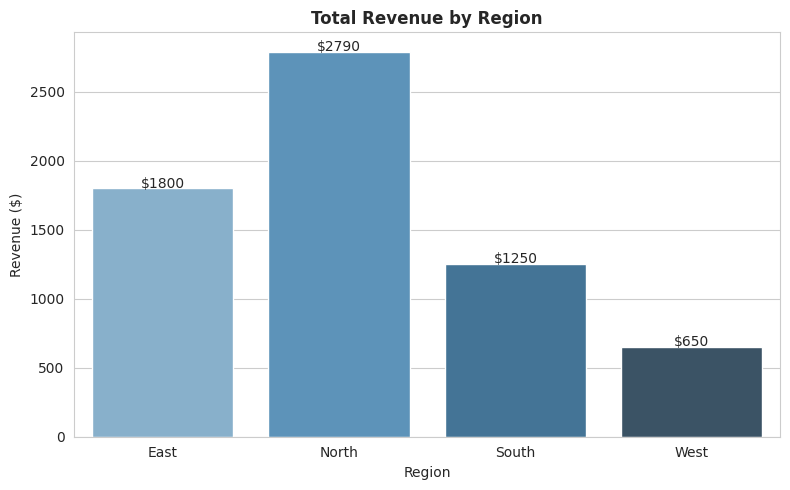

In [13]:
# Example: Run a SQL query directly and visualise
query = "SELECT region, SUM(price * quantity) as total_revenue FROM sales JOIN products ON sales.product_id = products.product_id GROUP BY region"
df_rev = pd.read_sql(query, sqlite3.connect("finance.db"))

plt.figure(figsize=(8,5))
sns.barplot(data=df_rev, x='region', y='total_revenue', palette='Blues_d')
plt.title('Total Revenue by Region', fontweight='bold')
plt.ylabel('Revenue ($)')
plt.xlabel('Region')
for i, row in df_rev.iterrows():
    plt.text(i, row['total_revenue'] + 5, f"${row['total_revenue']:.0f}", ha='center')
plt.tight_layout()
plt.show()

### Save Database to Google Drive (Optional)

In [14]:
from google.colab import drive
drive.mount('/content/drive')
!cp finance.db /content/drive/MyDrive/finance.db
print("Database saved to Google Drive at /content/drive/MyDrive/finance.db")

Mounted at /content/drive
Database saved to Google Drive at /content/drive/MyDrive/finance.db


### Final Summary

In [15]:
print("\n" + "="*50)
print("Financial Analyst (Text-to-SQL) - COMPLETED")
print("Author: Ibrahim")
print("="*50)
print(" Natural language to SQL pipeline is functional.")
print(" You can ask any business question about sales, products, customers.")
print(" The agent translates to SQL, executes, and explains results.")
print(" Database saved for reuse.")
print("\nThis project demonstrates a core RAG pattern: bridging language and structured data.")


Financial Analyst (Text-to-SQL) - COMPLETED
Author: Ibrahim
 Natural language to SQL pipeline is functional.
 You can ask any business question about sales, products, customers.
 The agent translates to SQL, executes, and explains results.
 Database saved for reuse.

This project demonstrates a core RAG pattern: bridging language and structured data.
